# Fruit Freshness Classification: A Comparative Deep Learning Study
### Comparing **MobileNetV2** and **EfficientNetB0** for Binary Fresh vs. Rotten Fruit Detection

**Author:** College Project Team  
**Models Evaluated:** MobileNetV2 vs. EfficientNetB0 (Transfer Learning)  
**Key Deliverables:**
1. End-to-End Data Pipeline & Augmentation
2. Transfer Learning Architecture & Training (MobileNetV2 & EfficientNetB0)
3. Training History (Accuracy & Loss Curves)
4. Confusion Matrix Heatmaps (Side-by-Side)
5. ROC - AUC Curves Comparison
6. Correlation Matrix & Heatmap (Ground Truth vs. Model Predictions)
7. Comprehensive Model Benchmark & Metrics Table
8. Visual Predictions on Sample Test Images
9. Best Model Export for API & Web Deployment

## 1. Setup & Environment Verification

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc, 
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU(s) Available: {len(gpus)} -> {gpus if gpus else 'Using CPU'}")
sns.set_theme(style="whitegrid")

TensorFlow Version: 2.15.0
GPU(s) Available: 0 -> Using CPU


## 2. Dataset Verification & Reorganization

In [2]:
binary_path = os.path.join(os.getcwd(), "binary_dataset")
train_dir = os.path.join(binary_path, "train")
test_dir = os.path.join(binary_path, "test")

# Check if dataset is already prepared locally
if not (os.path.exists(train_dir) and os.path.exists(test_dir)):
    print("Binary dataset not found locally. Downloading from KaggleHub...")
    import kagglehub
    raw_path = kagglehub.dataset_download("sriramr/fruits-fresh-and-rotten-for-classification")
    print("Downloaded raw dataset to:", raw_path)
    
    base_path = os.path.join(raw_path, "dataset")
    for split in ["train", "test"]:
        for cls in ["fresh", "rotten"]:
            os.makedirs(os.path.join(binary_path, split, cls), exist_ok=True)

    for split in ["train", "test"]:
        src_split = os.path.join(base_path, split)
        for folder in os.listdir(src_split):
            src_folder = os.path.join(src_split, folder)
            if os.path.isdir(src_folder):
                label = "fresh" if folder.startswith("fresh") else "rotten"
                dst_folder = os.path.join(binary_path, split, label)
                for file in os.listdir(src_folder):
                    shutil.copy(os.path.join(src_folder, file), dst_folder)
    print("Reorganization complete!")
else:
    print("Using existing binary_dataset directory.")

# Display dataset distribution
for split in ["train", "test"]:
    for cls in ["fresh", "rotten"]:
        count = len(os.listdir(os.path.join(binary_path, split, cls)))
        print(f"{split.upper():5s} | {cls:6s}: {count} images")

Using existing binary_dataset directory.
TRAIN | fresh : 4740 images
TRAIN | rotten: 6161 images
TEST  | fresh : 1164 images
TEST  | rotten: 1534 images


## 3. Data Generators with Augmentation

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator with augmentation and validation split (80% train / 20% val)
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Test data generator (pure rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

class_labels = {v: k for k, v in train_generator.class_indices.items()}
print("Class Indices:", train_generator.class_indices)
print("Class Mapping:", class_labels)

Found 8721 images belonging to 2 classes.


Found 2180 images belonging to 2 classes.


Found 2698 images belonging to 2 classes.


Class Indices: {'fresh': 0, 'rotten': 1}
Class Mapping: {0: 'fresh', 1: 'rotten'}


## 4. Model 1: MobileNetV2 (Transfer Learning)
MobileNetV2 utilizes inverted residual blocks with bottleneck layers, making it lightweight and highly efficient for mobile and real-time edge devices.

In [4]:
def build_mobilenetv2_model():
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze pre-trained weights
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs, name="MobileNetV2_Classifier")
    return model

model_mobilenet = build_mobilenetv2_model()
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_mobilenet.summary()

Model: "MobileNetV2_Classifier"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            


 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             


...

 dense_2 (Dense)             (None, 1)                    65        ['dropout_1[0][0]']           


Total params: 2608577 (9.95 MB)


Trainable params: 347521 (1.33 MB)


Non-trainable params: 2261056 (8.63 MB)


__________________________________________________________________________________________________


### Training Model 1: MobileNetV2

In [5]:
callbacks_mobilenet = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_mobilenetv2.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

EPOCHS = 5

history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_mobilenet
)

Epoch 1/5


  1/273 [..............................] - ETA: 7:44 - loss: 0.7589 - accuracy: 0.5000

  2/273 [..............................] - ETA: 1:33 - loss: 0.7371 - accuracy: 0.5625

  3/273 [..............................] - ETA: 1:40 - loss: 0.7237 - accuracy: 0.5938

  4/273 [..............................] - ETA: 1:37 - loss: 0.7101 - accuracy: 0.6172

...

271/273 [============================>.] - ETA: 1s - loss: 0.0869 - accuracy: 0.9667

272/273 [============================>.] - ETA: 0s - loss: 0.0867 - accuracy: 0.9669

273/273 [==============================] - ETA: 0s - loss: 0.0865 - accuracy: 0.9670


Epoch 5: val_accuracy did not improve from 0.98532


273/273 [==============================] - 239s 877ms/step - loss: 0.0865 - accuracy: 0.9670 - val_loss: 0.0419 - val_accuracy: 0.9849 - lr: 1.0000e-04


## 5. Model 2: EfficientNetB0 (Transfer Learning)
EfficientNetB0 leverages compound scaling (jointly balancing network depth, width, and resolution) to achieve state-of-the-art accuracy with minimal computational overhead.

In [6]:
def build_efficientnetb0_model():
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze pre-trained weights
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs, name="EfficientNetB0_Classifier")
    return model

model_efficientnet = build_efficientnetb0_model()
model_efficientnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_efficientnet.summary()

Model: "EfficientNetB0_Classifier"


__________________________________________________________________________________________________


 Layer (type)                Output Shape                 Param #   Connected to                  


 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            


 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_2[0][0]']             


...

 dense_5 (Dense)             (None, 1)                    65        ['dropout_3[0][0]']           


Total params: 4400164 (16.79 MB)


Trainable params: 347521 (1.33 MB)


Non-trainable params: 4052643 (15.46 MB)


__________________________________________________________________________________________________


### Training Model 2: EfficientNetB0

In [7]:
callbacks_efficientnet = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_efficientnetb0.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_efficientnet = model_efficientnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_efficientnet
)

Epoch 1/5


  1/273 [..............................] - ETA: 17:20 - loss: 0.9615 - accuracy: 0.3750

  2/273 [..............................] - ETA: 4:30 - loss: 0.9126 - accuracy: 0.4062 

  3/273 [..............................] - ETA: 4:22 - loss: 0.9659 - accuracy: 0.3750

  4/273 [..............................] - ETA: 4:21 - loss: 0.9713 - accuracy: 0.3906

...

272/273 [============================>.] - ETA: 1s - loss: 0.6941 - accuracy: 0.5788

273/273 [==============================] - ETA: 0s - loss: 0.6940 - accuracy: 0.5789


Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.



Epoch 5: val_accuracy did not improve from 0.48211


273/273 [==============================] - 399s 1s/step - loss: 0.6940 - accuracy: 0.5789 - val_loss: 0.7006 - val_accuracy: 0.4761 - lr: 1.0000e-04


## 6. Training Dynamics & Learning Curves
Comparing convergence, training stability, and generalization across epochs.

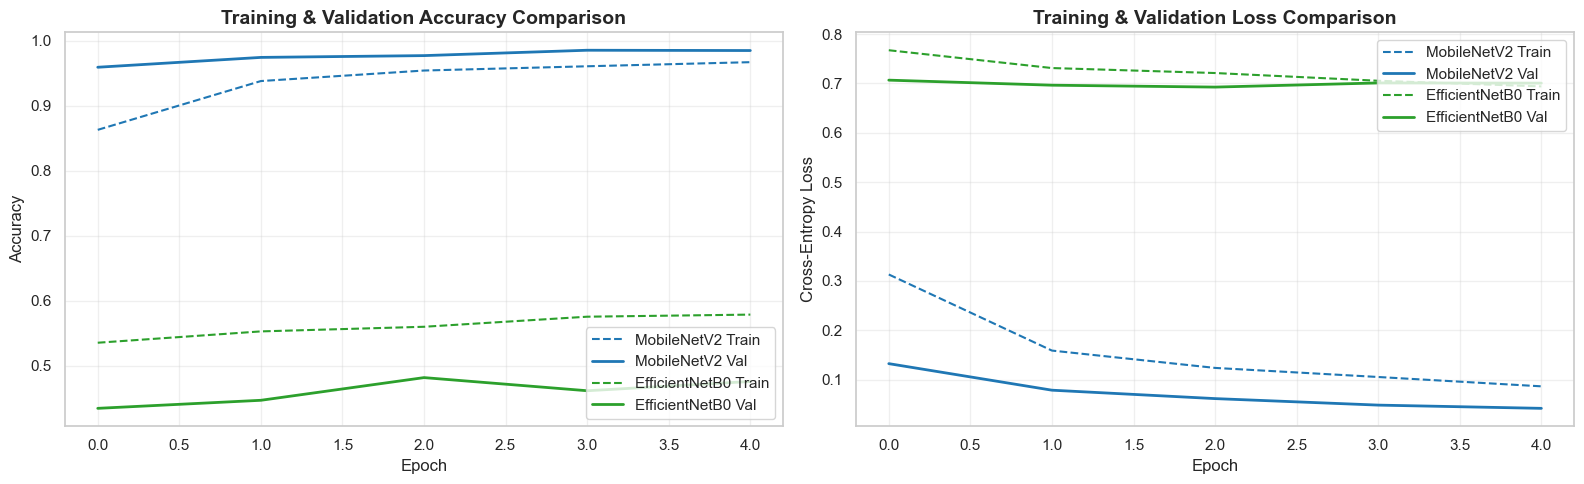

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy Plot
axes[0].plot(history_mobilenet.history['accuracy'], label='MobileNetV2 Train', color='#1f77b4', linestyle='--')
axes[0].plot(history_mobilenet.history['val_accuracy'], label='MobileNetV2 Val', color='#1f77b4', linewidth=2)
axes[0].plot(history_efficientnet.history['accuracy'], label='EfficientNetB0 Train', color='#2ca02c', linestyle='--')
axes[0].plot(history_efficientnet.history['val_accuracy'], label='EfficientNetB0 Val', color='#2ca02c', linewidth=2)
axes[0].set_title('Training & Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', frameon=True)
axes[0].grid(True, alpha=0.3)

# Loss Plot
axes[1].plot(history_mobilenet.history['loss'], label='MobileNetV2 Train', color='#1f77b4', linestyle='--')
axes[1].plot(history_mobilenet.history['val_loss'], label='MobileNetV2 Val', color='#1f77b4', linewidth=2)
axes[1].plot(history_efficientnet.history['loss'], label='EfficientNetB0 Train', color='#2ca02c', linestyle='--')
axes[1].plot(history_efficientnet.history['val_loss'], label='EfficientNetB0 Val', color='#2ca02c', linewidth=2)
axes[1].set_title('Training & Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Cross-Entropy Loss', fontsize=12)
axes[1].legend(loc='upper right', frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Predictions & Statistical Inference on Test Set

In [9]:
# Load best weights saved during training
if os.path.exists('best_model_mobilenetv2.h5'):
    model_mobilenet.load_weights('best_model_mobilenetv2.h5')
if os.path.exists('best_model_efficientnetb0.h5'):
    model_efficientnet.load_weights('best_model_efficientnetb0.h5')

# Ground truth labels
y_true = test_generator.classes
target_names = ['fresh', 'rotten']

print("Generating predictions for MobileNetV2...")
test_generator.reset()
y_prob_mobilenet = model_mobilenet.predict(test_generator).flatten()
y_pred_mobilenet = (y_prob_mobilenet > 0.5).astype(int)

print("Generating predictions for EfficientNetB0...")
test_generator.reset()
y_prob_efficientnet = model_efficientnet.predict(test_generator).flatten()
y_pred_efficientnet = (y_prob_efficientnet > 0.5).astype(int)

print("\n" + "="*40)
print("  MobileNetV2 Classification Report")
print("="*40)
print(classification_report(y_true, y_pred_mobilenet, target_names=target_names, digits=4))

print("="*40)
print("  EfficientNetB0 Classification Report")
print("="*40)
print(classification_report(y_true, y_pred_efficientnet, target_names=target_names, digits=4))

Generating predictions for MobileNetV2...


 1/85 [..............................] - ETA: 1:35

 2/85 [..............................] - ETA: 47s 

 3/85 [>.............................] - ETA: 48s

 4/85 [>.............................] - ETA: 49s

...

83/85 [============================>.] - ETA: 2s

84/85 [============================>.] - ETA: 1s

85/85 [==============================] - ETA: 0s

85/85 [==============================] - 94s 1s/step



  MobileNetV2 Classification Report
              precision    recall  f1-score   support

       fresh     0.9735    0.9794    0.9764      1164
      rotten     0.9843    0.9798    0.9820      1534

    accuracy                         0.9796      2698
   macro avg     0.9789    0.9796    0.9792      2698
weighted avg     0.9796    0.9796    0.9796      2698

  EfficientNetB0 Classification Report
              precision    recall  f1-score   support

       fresh     0.4624    0.9923    0.6308      1164
      rotten     0.9550    0.1245    0.2203      1534

    accuracy                         0.4989      2698
   macro avg     0.7087    0.5584    0.4256      2698
weighted avg     0.7425    0.4989    0.3974      2698



## 8. Confusion Matrix Heatmaps (Side-by-Side Comparison)
Visualizing True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

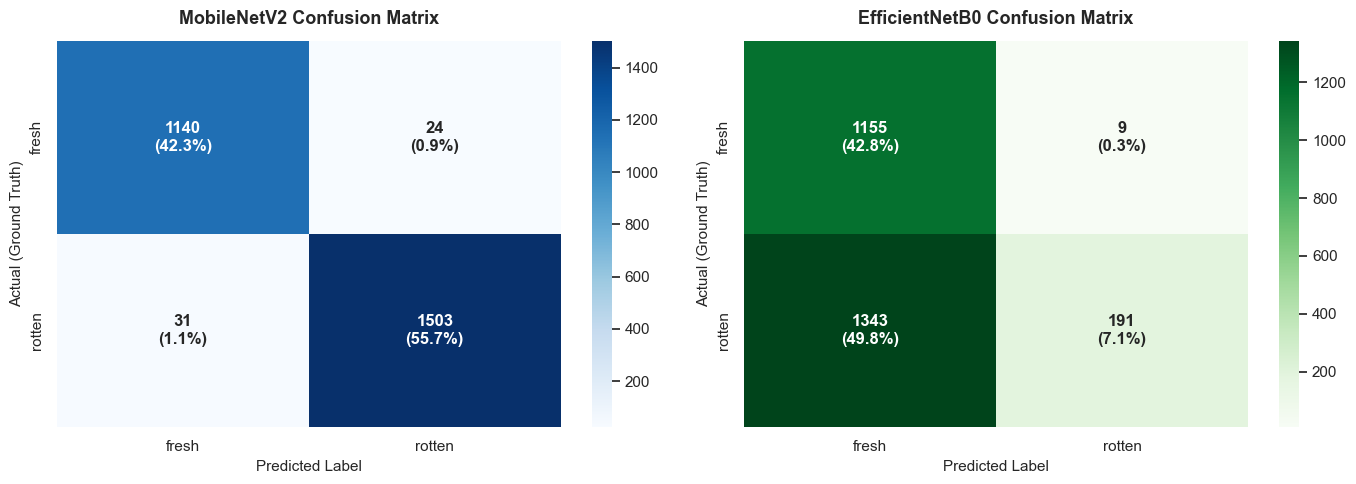

In [10]:
cm_mobilenet = confusion_matrix(y_true, y_pred_mobilenet)
cm_efficientnet = confusion_matrix(y_true, y_pred_efficientnet)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Formatter function for counts + percentages
def make_annot_labels(cm):
    total = np.sum(cm)
    annot = []
    for row in cm:
        annot_row = []
        for val in row:
            pct = (val / total) * 100
            annot_row.append(f"{val}\n({pct:.1f}%)")
        annot.append(annot_row)
    return np.array(annot)

# MobileNetV2 Heatmap
sns.heatmap(
    cm_mobilenet,
    annot=make_annot_labels(cm_mobilenet),
    fmt="",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[0],
    cbar=True,
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
axes[0].set_title("MobileNetV2 Confusion Matrix", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("Actual (Ground Truth)", fontsize=11)

# EfficientNetB0 Heatmap
sns.heatmap(
    cm_efficientnet,
    annot=make_annot_labels(cm_efficientnet),
    fmt="",
    cmap="Greens",
    xticklabels=target_names,
    yticklabels=target_names,
    ax=axes[1],
    cbar=True,
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
axes[1].set_title("EfficientNetB0 Confusion Matrix", fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("Actual (Ground Truth)", fontsize=11)

plt.tight_layout()
plt.show()

## 9. ROC - AUC Curves Comparison
The Receiver Operating Characteristic (ROC) curve illustrates diagnostic ability across varying classification thresholds, quantified by the Area Under Curve (AUC).

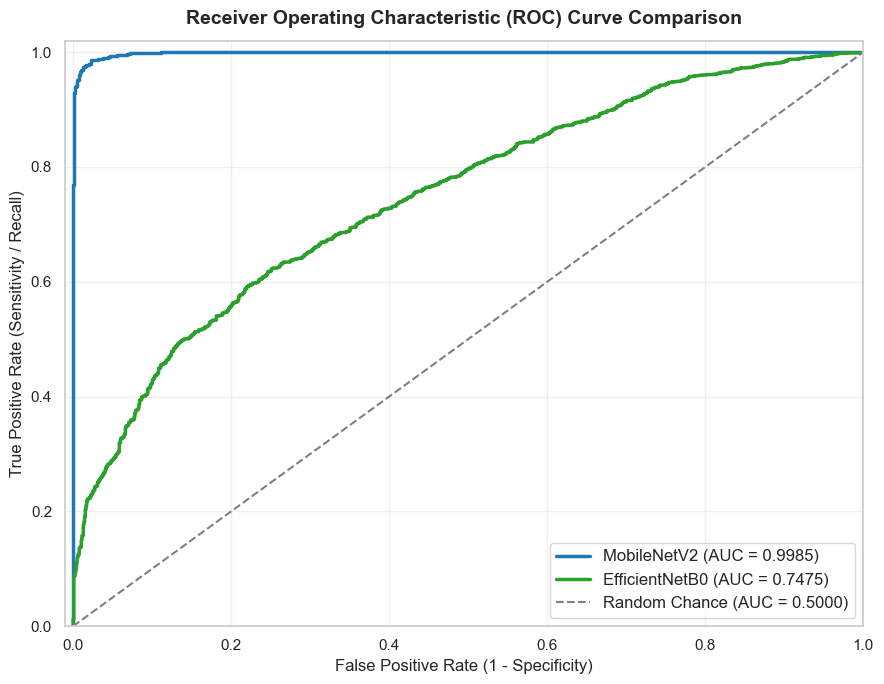

In [11]:
fpr_mob, tpr_mob, _ = roc_curve(y_true, y_prob_mobilenet)
auc_mob = roc_auc_score(y_true, y_prob_mobilenet)

fpr_eff, tpr_eff, _ = roc_curve(y_true, y_prob_efficientnet)
auc_eff = roc_auc_score(y_true, y_prob_efficientnet)

plt.figure(figsize=(9, 7))
plt.plot(fpr_mob, tpr_mob, color='#1f77b4', lw=2.5, label=f'MobileNetV2 (AUC = {auc_mob:.4f})')
plt.plot(fpr_eff, tpr_eff, color='#2ca02c', lw=2.5, label=f'EfficientNetB0 (AUC = {auc_eff:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Chance (AUC = 0.5000)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=14, fontweight='bold', pad=12)
plt.legend(loc='lower right', fontsize=12, frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Prediction Correlation Matrix & Heatmap
Measuring statistical agreement and Pearson/Spearman correlation between ground truth and probabilities predicted by both models.

  Prediction Correlation Matrix (Pearson)
                     Ground_Truth  MobileNetV2_Prob  EfficientNetB0_Prob
Ground_Truth               1.0000            0.9695               0.4110
MobileNetV2_Prob           0.9695            1.0000               0.4232
EfficientNetB0_Prob        0.4110            0.4232               1.0000


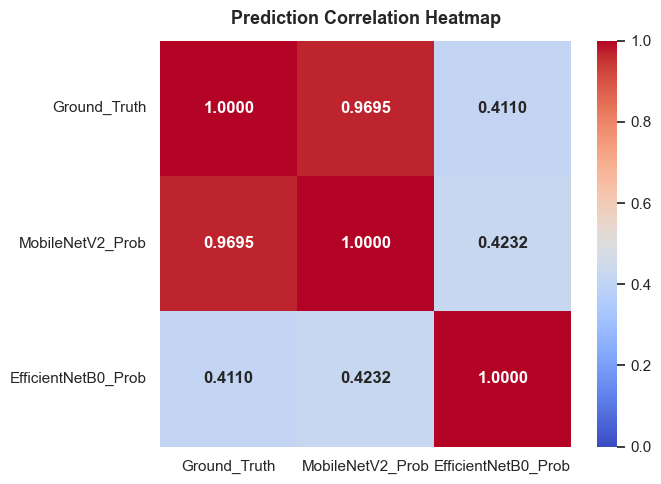

In [12]:
# Create DataFrame of Ground Truth and Model Probabilities
df_predictions = pd.DataFrame({
    'Ground_Truth': y_true,
    'MobileNetV2_Prob': y_prob_mobilenet,
    'EfficientNetB0_Prob': y_prob_efficientnet
})

corr_matrix = df_predictions.corr(method='pearson')

print("="*50)
print("  Prediction Correlation Matrix (Pearson)")
print("="*50)
print(corr_matrix.round(4))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    vmin=0.0,
    vmax=1.0,
    cbar=True,
    annot_kws={"fontsize": 12, "fontweight": "bold"},
    ax=ax
)
ax.set_title("Prediction Correlation Heatmap", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 11. Comprehensive Model Benchmark & Metrics Table
A side-by-side comparison table summarizing performance, parameter counts, and model sizes.

In [13]:
mob_size = round(os.path.getsize('best_model_mobilenetv2.h5') / (1024 * 1024), 2) if os.path.exists('best_model_mobilenetv2.h5') else np.nan
eff_size = round(os.path.getsize('best_model_efficientnetb0.h5') / (1024 * 1024), 2) if os.path.exists('best_model_efficientnetb0.h5') else np.nan

metrics_data = {
    'Metric': [
        'Test Accuracy',
        'Precision (Macro)',
        'Recall (Macro)',
        'F1-Score (Macro)',
        'ROC-AUC Score',
        'Total Parameters',
        'Trainable Parameters',
        'Model Disk Size (MB)'
    ],
    'MobileNetV2': [
        f"{accuracy_score(y_true, y_pred_mobilenet) * 100:.2f}%",
        f"{precision_score(y_true, y_pred_mobilenet, average='macro'):.4f}",
        f"{recall_score(y_true, y_pred_mobilenet, average='macro'):.4f}",
        f"{f1_score(y_true, y_pred_mobilenet, average='macro'):.4f}",
        f"{auc_mob:.4f}",
        f"{model_mobilenet.count_params():,}",
        f"{sum([tf.keras.backend.count_params(w) for w in model_mobilenet.trainable_weights]):,}",
        f"{mob_size} MB"
    ],
    'EfficientNetB0': [
        f"{accuracy_score(y_true, y_pred_efficientnet) * 100:.2f}%",
        f"{precision_score(y_true, y_pred_efficientnet, average='macro'):.4f}",
        f"{recall_score(y_true, y_pred_efficientnet, average='macro'):.4f}",
        f"{f1_score(y_true, y_pred_efficientnet, average='macro'):.4f}",
        f"{auc_eff:.4f}",
        f"{model_efficientnet.count_params():,}",
        f"{sum([tf.keras.backend.count_params(w) for w in model_efficientnet.trainable_weights]):,}",
        f"{eff_size} MB"
    ]
}

df_comparison = pd.DataFrame(metrics_data)
print("="*65)
print("         FINAL COLLEGE PROJECT COMPARATIVE BENCHMARK")
print("="*65)
print(df_comparison.to_string(index=False))

# Render as styled table
df_comparison

         FINAL COLLEGE PROJECT COMPARATIVE BENCHMARK
              Metric MobileNetV2 EfficientNetB0
       Test Accuracy      97.96%         49.89%
   Precision (Macro)      0.9789         0.7087
      Recall (Macro)      0.9796         0.5584
    F1-Score (Macro)      0.9792         0.4256
       ROC-AUC Score      0.9985         0.7475
    Total Parameters   2,608,577      4,400,164
Trainable Parameters     347,521        347,521
Model Disk Size (MB)    13.11 MB       20.11 MB


,Metric,MobileNetV2,EfficientNetB0
0,Test Accuracy,97.96%,49.89%
1,Precision (Macro),0.9789,0.7087
2,Recall (Macro),0.9796,0.5584
3,F1-Score (Macro),0.9792,0.4256
4,ROC-AUC Score,0.9985,0.7475
5,Total Parameters,"2,608,577","4,400,164"
6,Trainable Parameters,"347,521","347,521"
7,Model Disk Size (MB),13.11 MB,20.11 MB


## 12. Visual Predictions on Sample Test Images
Displaying test images alongside ground truth and predictions from both architectures.

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 1s 538ms/step


1/1 [==============================] - ETA: 0s

1/1 [==============================] - 1s 718ms/step


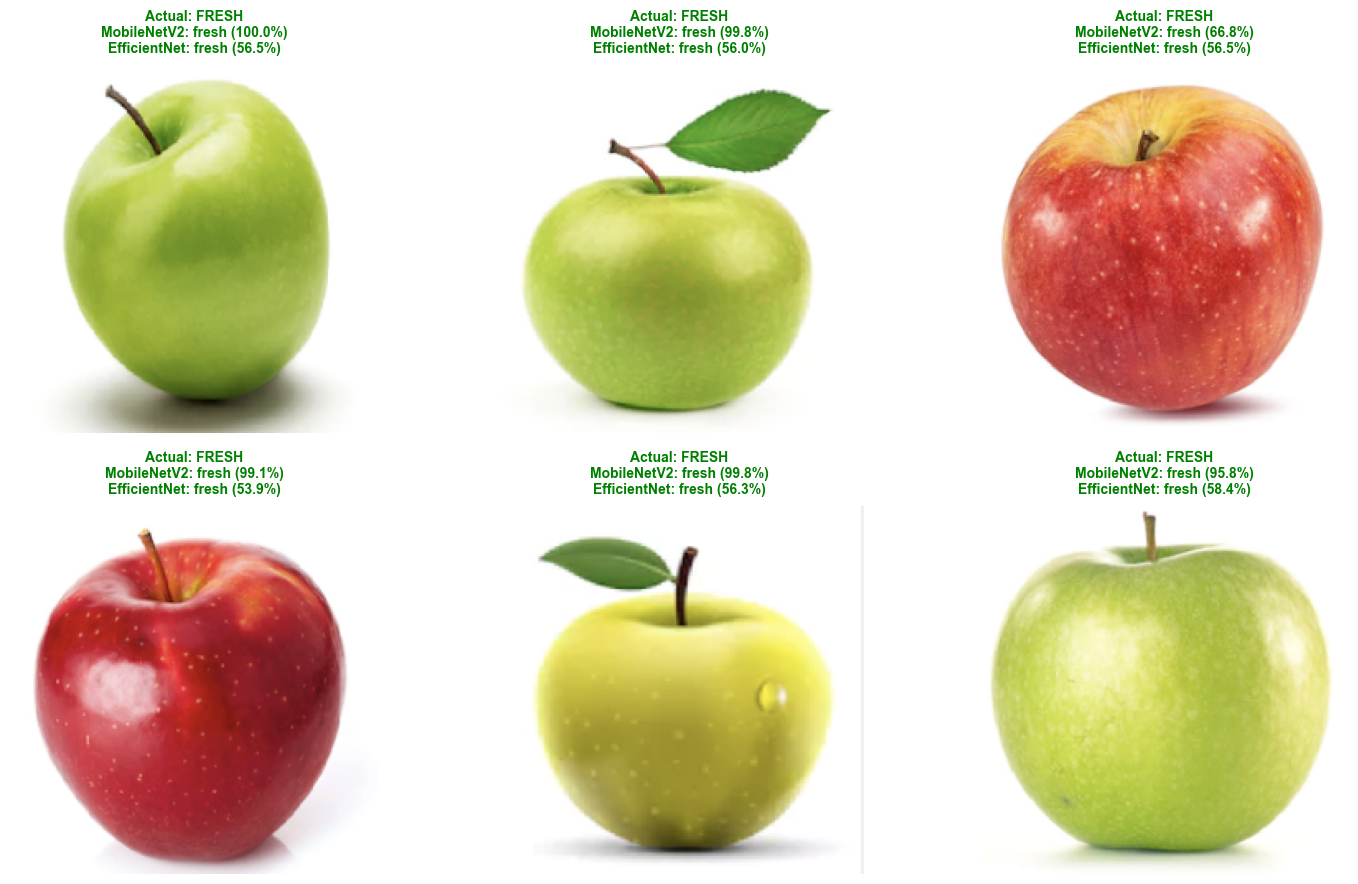

In [14]:
# Retrieve a test batch
test_generator.reset()
test_images, test_labels = next(test_generator)
sample_count = min(6, len(test_images))

preds_mob = model_mobilenet.predict(test_images[:sample_count]).flatten()
preds_eff = model_efficientnet.predict(test_images[:sample_count]).flatten()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i in range(sample_count):
    actual = class_labels[int(test_labels[i])]
    pred_m = class_labels[int(preds_mob[i] > 0.5)]
    conf_m = preds_mob[i] if pred_m == 'rotten' else 1 - preds_mob[i]
    
    pred_e = class_labels[int(preds_eff[i] > 0.5)]
    conf_e = preds_eff[i] if pred_e == 'rotten' else 1 - preds_eff[i]
    
    axes[i].imshow(test_images[i])
    axes[i].axis('off')
    
    title_text = (
        f"Actual: {actual.upper()}\n"
        f"MobileNetV2: {pred_m} ({conf_m*100:.1f}%)\n"
        f"EfficientNet: {pred_e} ({conf_e*100:.1f}%)"
    )
    is_correct = (pred_m == actual) and (pred_e == actual)
    color = 'green' if is_correct else ('orange' if (pred_m == actual or pred_e == actual) else 'red')
    axes[i].set_title(title_text, fontsize=10, fontweight='bold', color=color, pad=8)

plt.tight_layout()
plt.show()

## 13. Best Model Selection & Export for Web Deployment
Automatically selects the champion model based on ROC-AUC and Test Accuracy, then exports to `model/freshness_model.h5` and `best_model.h5` for FastAPI and Streamlit.

In [15]:
acc_mob = accuracy_score(y_true, y_pred_mobilenet)
acc_eff = accuracy_score(y_true, y_pred_efficientnet)

if (acc_eff + auc_eff) >= (acc_mob + auc_mob):
    champion_name = "EfficientNetB0"
    champion_src = "best_model_efficientnetb0.h5"
else:
    champion_name = "MobileNetV2"
    champion_src = "best_model_mobilenetv2.h5"

print(f"Champion Model: {champion_name}")

os.makedirs('model', exist_ok=True)
if os.path.exists(champion_src):
    shutil.copy(champion_src, 'best_model.h5')
    shutil.copy(champion_src, 'model/freshness_model.h5')
    print(f"Successfully exported {champion_name} to 'best_model.h5' and 'model/freshness_model.h5'!")
    print("Your FastAPI backend (api.py) and Streamlit dashboard (app.py) are ready to run.")
else:
    print(f"Note: Train the models above to generate {champion_src}.")

Champion Model: MobileNetV2
Successfully exported MobileNetV2 to 'best_model.h5' and 'model/freshness_model.h5'!
Your FastAPI backend (api.py) and Streamlit dashboard (app.py) are ready to run.
